# 07 — Compact Multi-Horizon 24h Forecasting

**Mục tiêu:** kiểm chứng vai trò của các mô hình deep sequence trong bài toán phù hợp hơn: dùng **168 giờ quá khứ** để dự báo **24 giờ tiếp theo**.

Notebook này khác notebook 06 full-feature ở điểm chính:

- Các mô hình tabular/boosting chỉ dùng **compact summary features** thay vì hàng trăm đặc trưng engineered.
- Các mô hình deep learning nhận trực tiếp chuỗi 168 giờ để học representation.
- Nhờ đó, việc so sánh giữa tabular models và deep sequence models công bằng và dễ diễn giải hơn.

In [1]:
# =========================
# 1. Configuration
# =========================

from pathlib import Path
import time
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DATA_DIR = Path("data_05")
OUT_DIR = Path("outputs_07")
FIG_DIR = Path("figures_07")
MODEL_DIR = Path("models_07")
for d in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LOOKBACK = 168
HORIZON = 24
SAMPLE_STRIDE_HOURS = 6
DAYLIGHT_THRESHOLD = 1.0

RUN_EXPENSIVE_MODELS = True      
RUN_DEEP_MODELS = True
RUN_ENSEMBLE = True
RUN_PERMUTATION_IMPORTANCE = True

MAX_EPOCHS = 15
PATIENCE = 4
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MAX_EXPENSIVE_TRAIN_SAMPLES = 5000

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Load 20-year NASA POWER hourly data

Notebook đọc 4 file CSV đã tải thủ công từ NASA POWER trong thư mục `data_05/`.

In [2]:
# =========================
# 2. Load manually downloaded NASA POWER CSV files
# =========================

manual_files = [
    DATA_DIR / "nasa_power_errachidia_hourly_2004_2008_LST.csv",
    DATA_DIR / "nasa_power_errachidia_hourly_2009_2013_LST.csv",
    DATA_DIR / "nasa_power_errachidia_hourly_2014_2018_LST.csv",
    DATA_DIR / "nasa_power_errachidia_hourly_2019_2023_LST.csv",
]

missing = [str(p) for p in manual_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required NASA POWER files:\n" + "\n".join(missing))


def read_power_csv(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    header_idx = next((i for i, line in enumerate(lines) if line.strip().startswith("YEAR")), None)
    if header_idx is None:
        raise ValueError(f"Could not find YEAR header in {path}")
    return pd.read_csv(path, skiprows=header_idx)

parts = []
for path in manual_files:
    part = read_power_csv(path)
    parts.append(part)
    print(f"{path.name}: {part.shape}")

raw_df = pd.concat(parts, ignore_index=True)
raw_df = raw_df.drop_duplicates(subset=["YEAR", "MO", "DY", "HR"])
raw_df = raw_df.sort_values(["YEAR", "MO", "DY", "HR"]).reset_index(drop=True)

print("Combined raw shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.tail())

nasa_power_errachidia_hourly_2004_2008_LST.csv: (43848, 10)
nasa_power_errachidia_hourly_2009_2013_LST.csv: (43824, 10)
nasa_power_errachidia_hourly_2014_2018_LST.csv: (43824, 10)
nasa_power_errachidia_hourly_2019_2023_LST.csv: (43824, 10)
Combined raw shape: (175320, 10)


,YEAR,MO,DY,HR,PS,WS10M,WD10M,RH2M,ALLSKY_SFC_SW_DWN,T2M
0,2004,1,1,0,87.48,3.75,331.3,90.18,0.0,3.69
1,2004,1,1,1,87.49,4.01,336.3,93.09,0.0,3.38
2,2004,1,1,2,87.48,4.20,340.8,94.70,0.0,3.19
3,2004,1,1,3,87.45,4.40,342.8,95.65,0.0,2.99
4,2004,1,1,4,87.42,4.31,342.0,96.39,0.0,2.74


,YEAR,MO,DY,HR,PS,WS10M,WD10M,RH2M,ALLSKY_SFC_SW_DWN,T2M
175315,2023,12,31,19,87.44,3.05,189.8,30.12,0.0,7.60
175316,2023,12,31,20,87.48,2.89,205.6,32.86,0.0,6.53
175317,2023,12,31,21,87.49,2.75,218.7,34.88,0.0,5.86
175318,2023,12,31,22,87.49,2.53,227.7,35.23,0.0,5.90
175319,2023,12,31,23,87.46,2.32,232.5,35.37,0.0,5.84


## 3. Basic preprocessing and physical/time features

In [3]:
# =========================
# 3. Preprocess hourly data
# =========================

df = raw_df.copy()

rename_map = {
    "PS": "Pressure",
    "WS10M": "Wind_Speed",
    "WD10M": "Wind_Direction",
    "RH2M": "Humidity",
    "ALLSKY_SFC_SW_DWN": "Solar_Radiation_Wh_m2",
    "T2M": "Temperature",
}
df = df.rename(columns=rename_map)

required_cols = [
    "YEAR", "MO", "DY", "HR",
    "Pressure", "Wind_Speed", "Wind_Direction",
    "Humidity", "Solar_Radiation_Wh_m2", "Temperature",
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df["datetime"] = pd.to_datetime(
    dict(year=df["YEAR"], month=df["MO"], day=df["DY"], hour=df["HR"]),
    errors="coerce"
)
df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()

numeric_cols = ["Pressure", "Wind_Speed", "Wind_Direction", "Humidity", "Solar_Radiation_Wh_m2", "Temperature"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)
df[numeric_cols] = df[numeric_cols].interpolate(limit_direction="both").ffill().bfill()

# Unit conversion
df["Solar_Radiation_Wh_m2"] = df["Solar_Radiation_Wh_m2"].clip(lower=0)
df["Solar_Energy_kJ_m2"] = df["Solar_Radiation_Wh_m2"] * 3.6

# Wind direction cyclic encoding
wind_rad = np.deg2rad(df["Wind_Direction"] % 360)
df["wind_dir_sin"] = np.sin(wind_rad)
df["wind_dir_cos"] = np.cos(wind_rad)

# Time cyclic features
hour = df.index.hour + 0.5
doy = df.index.dayofyear
month = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
df["month_sin"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)

# Simple solar geometry proxy for Errachidia
LATITUDE = 31.93

def solar_elevation_proxy(index, latitude_deg=LATITUDE):
    lat = np.deg2rad(latitude_deg)
    day = index.dayofyear.values
    local_hour = index.hour.values + 0.5
    decl = np.deg2rad(23.44 * np.sin(2 * np.pi * (284 + day) / 365.25))
    hour_angle = np.deg2rad(15 * (local_hour - 12))
    sin_elev = np.sin(lat) * np.sin(decl) + np.cos(lat) * np.cos(decl) * np.cos(hour_angle)
    elev = np.rad2deg(np.arcsin(np.clip(sin_elev, -1, 1)))
    return elev

df["solar_elevation_proxy_deg"] = solar_elevation_proxy(df.index)
df["sun_up_proxy"] = (df["solar_elevation_proxy_deg"] > 0).astype(int)
df["clear_sky_ghi_proxy_Wh_m2"] = np.maximum(0, np.sin(np.deg2rad(df["solar_elevation_proxy_deg"]))) * 1000

df["clear_sky_index_proxy"] = np.where(
    df["clear_sky_ghi_proxy_Wh_m2"] > 10,
    df["Solar_Radiation_Wh_m2"] / df["clear_sky_ghi_proxy_Wh_m2"],
    0,
)
df["clear_sky_index_proxy"] = df["clear_sky_index_proxy"].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 2)

# Simple PVWatts-style proxy
NOCT = 45
gamma_pdc = -0.004
cell_temp = df["Temperature"] + (NOCT - 20) / 800 * df["Solar_Radiation_Wh_m2"]
dc_power = (df["Solar_Radiation_Wh_m2"] / 1000) * (1 + gamma_pdc * (cell_temp - 25))
df["sim_pv_ac_kWh_per_kWp"] = (dc_power * 0.96).clip(lower=0)

df = df.replace([np.inf, -np.inf], np.nan).ffill().bfill()

print("Hourly dataframe:", df.shape, df.index.min(), "→", df.index.max())
print("Missing values in core columns:")
print(df[["Solar_Energy_kJ_m2", "Temperature", "Humidity", "Pressure", "Wind_Speed"]].isna().sum())
display(df.head())

Hourly dataframe: (175320, 24) 2004-01-01 00:00:00 → 2023-12-31 23:00:00
Missing values in core columns:
Solar_Energy_kJ_m2    0
Temperature           0
Humidity              0
Pressure              0
Wind_Speed            0
dtype: int64


,YEAR,MO,DY,HR,Pressure,Wind_Speed,Wind_Direction,Humidity,Solar_Radiation_Wh_m2,Temperature,...,hour_cos,doy_sin,doy_cos,month_sin,month_cos,solar_elevation_proxy_deg,sun_up_proxy,clear_sky_ghi_proxy_Wh_m2,clear_sky_index_proxy,sim_pv_ac_kWh_per_kWp
datetime,,,,,,,,,,,,,,,,,,,,,
2004-01-01 00:00:00,2004,1,1,0,87.48,3.75,331.3,90.18,0.0,3.69,...,0.991445,0.017202,0.999852,0.5,0.866025,-78.884823,0,0.0,0.0,0.0
2004-01-01 01:00:00,2004,1,1,1,87.49,4.01,336.3,93.09,0.0,3.38,...,0.923880,0.017202,0.999852,0.5,0.866025,-68.196681,0,0.0,0.0,0.0
2004-01-01 02:00:00,2004,1,1,2,87.48,4.20,340.8,94.70,0.0,3.19,...,0.793353,0.017202,0.999852,0.5,0.866025,-55.741511,0,0.0,0.0,0.0
2004-01-01 03:00:00,2004,1,1,3,87.45,4.40,342.8,95.65,0.0,2.99,...,0.608761,0.017202,0.999852,0.5,0.866025,-43.024892,0,0.0,0.0,0.0
2004-01-01 04:00:00,2004,1,1,4,87.42,4.31,342.0,96.39,0.0,2.74,...,0.382683,0.017202,0.999852,0.5,0.866025,-30.379137,0,0.0,0.0,0.0


## 4. Build multi-horizon sequence dataset

Input: `LOOKBACK = 168` giờ quá khứ.  
Output: `HORIZON = 24` giờ tiếp theo.

In [4]:
# =========================
# 4. Build 168h → 24h dataset
# =========================

sequence_features = [
    "Solar_Energy_kJ_m2",
    "Solar_Radiation_Wh_m2",
    "Temperature",
    "Humidity",
    "Pressure",
    "Wind_Speed",
    "wind_dir_sin",
    "wind_dir_cos",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "month_sin",
    "month_cos",
    "solar_elevation_proxy_deg",
    "sun_up_proxy",
    "clear_sky_ghi_proxy_Wh_m2",
    "clear_sky_index_proxy",
    "sim_pv_ac_kWh_per_kWp",
]
sequence_features = [c for c in sequence_features if c in df.columns]
target_col = "Solar_Energy_kJ_m2"

values = df[sequence_features].astype(np.float32).values
target_values = df[target_col].astype(np.float32).values
times = df.index

X_list, Y_list, anchor_times, target_end_times = [], [], [], []
for start in range(LOOKBACK, len(df) - HORIZON + 1, SAMPLE_STRIDE_HOURS):
    X_list.append(values[start - LOOKBACK:start])
    Y_list.append(target_values[start:start + HORIZON])
    anchor_times.append(times[start])
    target_end_times.append(times[start + HORIZON - 1])

X_all = np.stack(X_list).astype(np.float32)
Y_all = np.stack(Y_list).astype(np.float32)
anchor_times = pd.DatetimeIndex(anchor_times)
target_end_times = pd.DatetimeIndex(target_end_times)

print("X_all:", X_all.shape)
print("Y_all:", Y_all.shape)
print("Sequence features:", len(sequence_features))
print("Anchor hour distribution:")
print(pd.Series(anchor_times.hour).value_counts().sort_index())

X_all: (29189, 168, 19)
Y_all: (29189, 24)
Sequence features: 19
Anchor hour distribution:
0     7298
6     7297
12    7297
18    7297
Name: count, dtype: int64


In [5]:
# =========================
# 5. Time-based split
# =========================

train_mask = target_end_times <= pd.Timestamp("2018-12-31 23:00:00")
val_mask = (anchor_times >= pd.Timestamp("2019-01-01 00:00:00")) & (target_end_times <= pd.Timestamp("2020-12-31 23:00:00"))
test_mask = (anchor_times >= pd.Timestamp("2021-01-01 00:00:00")) & (target_end_times <= pd.Timestamp("2023-12-31 23:00:00"))

X_train_raw, Y_train = X_all[train_mask], Y_all[train_mask]
X_val_raw, Y_val = X_all[val_mask], Y_all[val_mask]
X_test_raw, Y_test = X_all[test_mask], Y_all[test_mask]

train_times = anchor_times[train_mask]
val_times = anchor_times[val_mask]
test_times = anchor_times[test_mask]

print("Train:", X_train_raw.shape, Y_train.shape, train_times.min(), "→", train_times.max())
print("Val  :", X_val_raw.shape, Y_val.shape, val_times.min(), "→", val_times.max())
print("Test :", X_test_raw.shape, Y_test.shape, test_times.min(), "→", test_times.max())

# Scale sequence data for deep learning only
x_scaler = StandardScaler()
x_scaler.fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))

def scale_X(X):
    shape = X.shape
    return x_scaler.transform(X.reshape(-1, shape[-1])).reshape(shape).astype(np.float32)

X_train_seq = scale_X(X_train_raw)
X_val_seq = scale_X(X_val_raw)
X_test_seq = scale_X(X_test_raw)

y_scaler = StandardScaler()
y_scaler.fit(Y_train.reshape(-1, 1))
Y_train_scaled = y_scaler.transform(Y_train.reshape(-1, 1)).reshape(Y_train.shape).astype(np.float32)
Y_val_scaled = y_scaler.transform(Y_val.reshape(-1, 1)).reshape(Y_val.shape).astype(np.float32)
Y_test_scaled = y_scaler.transform(Y_test.reshape(-1, 1)).reshape(Y_test.shape).astype(np.float32)

Train: (21885, 168, 19) (21885, 24) 2004-01-08 00:00:00 → 2018-12-31 00:00:00
Val  : (2921, 168, 19) (2921, 24) 2019-01-01 00:00:00 → 2020-12-31 00:00:00
Test : (4377, 168, 19) (4377, 24) 2021-01-01 00:00:00 → 2023-12-31 00:00:00


## 5. Metrics and baselines

In [6]:
# =========================
# 6. Evaluation utilities
# =========================

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1))))


def ensure_2d_prediction(pred, horizon=HORIZON):
    pred = np.asarray(pred, dtype=np.float32)
    if pred.ndim == 1:
        if pred.size % horizon != 0:
            raise ValueError(f"Cannot reshape prediction of size {pred.size} to horizon={horizon}")
        pred = pred.reshape(-1, horizon)
    if pred.ndim != 2 or pred.shape[1] != horizon:
        raise ValueError(f"Prediction must have shape (n_samples, {horizon}), got {pred.shape}")
    return pred


def evaluate_24h(y_true, y_pred, persistence_pred=None, daylight_threshold=DAYLIGHT_THRESHOLD):
    y_true = ensure_2d_prediction(y_true)
    y_pred = ensure_2d_prediction(y_pred)

    n = min(len(y_true), len(y_pred))
    y_true = y_true[-n:]
    y_pred = np.clip(y_pred[-n:], 0, None)

    yt_flat = y_true.reshape(-1)
    yp_flat = y_pred.reshape(-1)

    overall_rmse = rmse(yt_flat, yp_flat)
    out = {
        "RMSE": overall_rmse,
        "MAE": float(mean_absolute_error(yt_flat, yp_flat)),
        "R2": float(r2_score(yt_flat, yp_flat)),
        "MaxError": float(max_error(yt_flat, yp_flat)),
        "NRMSE": float(overall_rmse / (yt_flat.max() - yt_flat.min())) if (yt_flat.max() - yt_flat.min()) != 0 else np.nan,
    }

    daylight_mask = yt_flat > daylight_threshold
    if daylight_mask.sum() > 5:
        out["daylight_RMSE"] = rmse(yt_flat[daylight_mask], yp_flat[daylight_mask])
        out["daylight_MAE"] = float(mean_absolute_error(yt_flat[daylight_mask], yp_flat[daylight_mask]))
        out["daylight_R2"] = float(r2_score(yt_flat[daylight_mask], yp_flat[daylight_mask]))
    else:
        out["daylight_RMSE"] = np.nan
        out["daylight_MAE"] = np.nan
        out["daylight_R2"] = np.nan

    # Horizon metrics
    out["h1_RMSE"] = rmse(y_true[:, 0], y_pred[:, 0])
    out["h12_RMSE"] = rmse(y_true[:, 11], y_pred[:, 11]) if y_true.shape[1] >= 12 else np.nan
    out["h24_RMSE"] = rmse(y_true[:, 23], y_pred[:, 23]) if y_true.shape[1] >= 24 else np.nan

    # Daily total from 24 predicted hours
    true_daily_total = y_true.sum(axis=1)
    pred_daily_total = y_pred.sum(axis=1)
    daily_rmse = rmse(true_daily_total, pred_daily_total)
    out["daily_total_RMSE"] = daily_rmse
    out["daily_total_MAE"] = float(mean_absolute_error(true_daily_total, pred_daily_total))
    out["daily_total_R2"] = float(r2_score(true_daily_total, pred_daily_total))

    if persistence_pred is not None:
        p = ensure_2d_prediction(persistence_pred)[-n:]
        p_flat = p.reshape(-1)
        mask = yt_flat > daylight_threshold
        if mask.sum() > 5:
            model_rmse = rmse(yt_flat[mask], yp_flat[mask])
            persistence_rmse = rmse(yt_flat[mask], p_flat[mask])
            out["skill_vs_persistence_daylight"] = float(1 - model_rmse / persistence_rmse) if persistence_rmse > 0 else np.nan
        else:
            out["skill_vs_persistence_daylight"] = np.nan
    else:
        out["skill_vs_persistence_daylight"] = np.nan

    return out


def print_metric_short(prefix, metrics):
    print(
        f"{prefix:<35} | "
        f"RMSE={metrics.get('RMSE', np.nan):9.3f} | "
        f"daylight_RMSE={metrics.get('daylight_RMSE', np.nan):9.3f} | "
        f"h1={metrics.get('h1_RMSE', np.nan):9.3f} | "
        f"h12={metrics.get('h12_RMSE', np.nan):9.3f} | "
        f"h24={metrics.get('h24_RMSE', np.nan):9.3f} | "
        f"daily_total_RMSE={metrics.get('daily_total_RMSE', np.nan):9.3f}"
    )


def add_result_row(rows, task, model_name, model_type, val_metrics, test_metrics, train_seconds, extra=None):
    row = {"task": task, "model": model_name, "model_type": model_type, "train_seconds": train_seconds}
    row.update({f"val_{k}": v for k, v in val_metrics.items()})
    row.update({f"test_{k}": v for k, v in test_metrics.items()})
    if extra:
        row.update(extra)
    rows.append(row)

In [7]:
# =========================
# 7. Baselines
# =========================

results = []
predictions = {}

# Current value repeated 24 steps
persistence_train = np.repeat(X_train_raw[:, -1, sequence_features.index("Solar_Energy_kJ_m2")][:, None], HORIZON, axis=1)
persistence_val = np.repeat(X_val_raw[:, -1, sequence_features.index("Solar_Energy_kJ_m2")][:, None], HORIZON, axis=1)
persistence_test = np.repeat(X_test_raw[:, -1, sequence_features.index("Solar_Energy_kJ_m2")][:, None], HORIZON, axis=1)

# Yesterday curve = last 24 hours in the input window
seasonal_yesterday_train = X_train_raw[:, -24:, sequence_features.index("Solar_Energy_kJ_m2")]
seasonal_yesterday_val = X_val_raw[:, -24:, sequence_features.index("Solar_Energy_kJ_m2")]
seasonal_yesterday_test = X_test_raw[:, -24:, sequence_features.index("Solar_Energy_kJ_m2")]

# Weekly curve = same 24h block one week earlier
weekly_train = X_train_raw[:, :24, sequence_features.index("Solar_Energy_kJ_m2")]
weekly_val = X_val_raw[:, :24, sequence_features.index("Solar_Energy_kJ_m2")]
weekly_test = X_test_raw[:, :24, sequence_features.index("Solar_Energy_kJ_m2")]

baseline_defs = {
    "Persistence_current": (persistence_val, persistence_test),
    "SeasonalPersistence_yesterday": (seasonal_yesterday_val, seasonal_yesterday_test),
    "SeasonalPersistence_weekly": (weekly_val, weekly_test),
}
reference_persistence_val = seasonal_yesterday_val
reference_persistence_test = seasonal_yesterday_test

for name, (val_pred, test_pred) in baseline_defs.items():
    val_metrics = evaluate_24h(Y_val, val_pred, persistence_pred=reference_persistence_val)
    test_metrics = evaluate_24h(Y_test, test_pred, persistence_pred=reference_persistence_test)
    add_result_row(results, "24h_multihorizon", name, "baseline", val_metrics, test_metrics, 0.0)
    predictions[name] = {"val_pred": val_pred, "test_pred": test_pred, "val_true": Y_val, "test_true": Y_test}
    print_metric_short(f"{name} Val", val_metrics)
    print_metric_short(f"{name} Test", test_metrics)

Persistence_current Val             | RMSE= 1687.211 | daylight_RMSE= 1861.680 | h1=  259.085 | h12= 2134.268 | h24=  213.080 | daily_total_RMSE=29791.583
Persistence_current Test            | RMSE= 1669.004 | daylight_RMSE= 1842.369 | h1=  260.564 | h12= 2111.038 | h24=  227.751 | daily_total_RMSE=29463.690
SeasonalPersistence_yesterday Val   | RMSE=  222.588 | daylight_RMSE=  309.332 | h1=  210.905 | h12=  213.080 | h24=  213.080 | daily_total_RMSE= 2684.912
SeasonalPersistence_yesterday Test  | RMSE=  244.328 | daylight_RMSE=  339.524 | h1=  228.916 | h12=  227.756 | h24=  227.751 | daily_total_RMSE= 3062.491
SeasonalPersistence_weekly Val      | RMSE=  275.416 | daylight_RMSE=  382.745 | h1=  249.535 | h12=  264.553 | h24=  264.551 | daily_total_RMSE= 3730.655
SeasonalPersistence_weekly Test     | RMSE=  293.976 | daylight_RMSE=  408.514 | h1=  273.216 | h12=  280.354 | h24=  280.151 | daily_total_RMSE= 3983.165


## 6. Compact tabular features

Các mô hình tabular/boosting chỉ dùng bộ đặc trưng tóm tắt gọn từ cửa sổ 168 giờ quá khứ, giúp so sánh công bằng hơn với deep sequence models.

In [8]:
# =========================
# 8. Compact tabular features
# =========================

def make_compact_tabular_features(X_raw, anchor_times, feature_cols):
    idx = {name: i for i, name in enumerate(feature_cols)}

    def get_series(x, name):
        return x[:, idx[name]] if name in idx else None

    def safe_value(series, pos):
        if series is None:
            return 0.0
        return float(series[pos])

    rows = []
    for sample_idx, x in enumerate(X_raw):
        row = {}

        # Solar-related lags: compact but informative
        for var in ["Solar_Energy_kJ_m2", "Solar_Radiation_Wh_m2", "sim_pv_ac_kWh_per_kWp", "clear_sky_index_proxy"]:
            s = get_series(x, var)
            if s is None:
                continue
            for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
                row[f"{var}_lag_{lag}h"] = safe_value(s, -lag)

        # Rolling summaries for target and radiation only
        for var in ["Solar_Energy_kJ_m2", "Solar_Radiation_Wh_m2"]:
            s = get_series(x, var)
            if s is None:
                continue
            for w in [3, 6, 24, 72, 168]:
                seg = s[-w:]
                row[f"{var}_mean_{w}h"] = float(np.mean(seg))
                row[f"{var}_std_{w}h"] = float(np.std(seg))
                row[f"{var}_max_{w}h"] = float(np.max(seg))

        # Weather: last value + 24h/168h mean
        for var in ["Temperature", "Humidity", "Pressure", "Wind_Speed", "wind_dir_sin", "wind_dir_cos"]:
            s = get_series(x, var)
            if s is None:
                continue
            row[f"{var}_last"] = float(s[-1])
            row[f"{var}_mean_24h"] = float(np.mean(s[-24:]))
            row[f"{var}_mean_168h"] = float(np.mean(s[-168:]))

        # Anchor time/physical state
        for var in ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "month_sin", "month_cos", "solar_elevation_proxy_deg", "sun_up_proxy"]:
            s = get_series(x, var)
            if s is not None:
                row[f"anchor_{var}"] = float(s[-1])

        # Known future calendar/solar-geometry summaries for the next 24h
        anchor = anchor_times[sample_idx]
        future_times = pd.date_range(anchor, periods=HORIZON, freq="h")
        future_hour = future_times.hour.values + 0.5
        future_doy = future_times.dayofyear.values
        future_month = future_times.month.values

        future_hour_sin = np.sin(2 * np.pi * future_hour / 24)
        future_hour_cos = np.cos(2 * np.pi * future_hour / 24)
        future_doy_sin = np.sin(2 * np.pi * future_doy / 365.25)
        future_doy_cos = np.cos(2 * np.pi * future_doy / 365.25)
        future_month_sin = np.sin(2 * np.pi * future_month / 12)
        future_month_cos = np.cos(2 * np.pi * future_month / 12)
        future_elev = solar_elevation_proxy(future_times)
        future_clear = np.maximum(0, np.sin(np.deg2rad(future_elev))) * 1000

        for h in [1, 12, 24]:
            k = h - 1
            row[f"future_h{h}_hour_sin"] = float(future_hour_sin[k])
            row[f"future_h{h}_hour_cos"] = float(future_hour_cos[k])
            row[f"future_h{h}_solar_elevation"] = float(future_elev[k])
            row[f"future_h{h}_clear_sky_proxy"] = float(future_clear[k])

        row["future_mean_solar_elevation"] = float(np.mean(future_elev))
        row["future_max_solar_elevation"] = float(np.max(future_elev))
        row["future_daylight_count"] = float(np.sum(future_elev > 0))
        row["future_mean_clear_sky_proxy"] = float(np.mean(future_clear))
        row["future_max_clear_sky_proxy"] = float(np.max(future_clear))
        row["future_doy_sin_mean"] = float(np.mean(future_doy_sin))
        row["future_doy_cos_mean"] = float(np.mean(future_doy_cos))
        row["future_month_sin_mean"] = float(np.mean(future_month_sin))
        row["future_month_cos_mean"] = float(np.mean(future_month_cos))

        rows.append(row)

    X_tab = pd.DataFrame(rows, index=anchor_times)
    X_tab = X_tab.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_tab = X_tab.loc[:, ~X_tab.columns.duplicated()].copy()
    return X_tab.astype(np.float32)

X_train_tab = make_compact_tabular_features(X_train_raw, train_times, sequence_features)
X_val_tab = make_compact_tabular_features(X_val_raw, val_times, sequence_features)
X_test_tab = make_compact_tabular_features(X_test_raw, test_times, sequence_features)

print("X_train_tab:", X_train_tab.shape, "| duplicated cols:", X_train_tab.columns.duplicated().sum())
print("X_val_tab  :", X_val_tab.shape, "| duplicated cols:", X_val_tab.columns.duplicated().sum())
print("X_test_tab :", X_test_tab.shape, "| duplicated cols:", X_test_tab.columns.duplicated().sum())
print("Compact tabular feature count:", X_train_tab.shape[1])
display(X_train_tab.head())

X_train_tab: (21885, 109) | duplicated cols: 0
X_val_tab  : (2921, 109) | duplicated cols: 0
X_test_tab : (4377, 109) | duplicated cols: 0
Compact tabular feature count: 109


,Solar_Energy_kJ_m2_lag_1h,Solar_Energy_kJ_m2_lag_2h,Solar_Energy_kJ_m2_lag_3h,Solar_Energy_kJ_m2_lag_6h,Solar_Energy_kJ_m2_lag_12h,Solar_Energy_kJ_m2_lag_24h,Solar_Energy_kJ_m2_lag_48h,Solar_Energy_kJ_m2_lag_168h,Solar_Radiation_Wh_m2_lag_1h,Solar_Radiation_Wh_m2_lag_2h,...,future_h24_clear_sky_proxy,future_mean_solar_elevation,future_max_solar_elevation,future_daylight_count,future_mean_clear_sky_proxy,future_max_clear_sky_proxy,future_doy_sin_mean,future_doy_cos_mean,future_month_sin_mean,future_month_cos_mean
2004-01-08 00:00:00,0.000000,0.000000,0.000000,0.000000,1875.312012,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-15.338805,35.279633,10.0,158.404938,577.567505,0.137185,0.990545,0.5,0.866025
2004-01-08 06:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-15.322691,35.279633,10.0,158.404938,577.567505,0.141440,0.989919,0.5,0.866025
2004-01-08 12:00:00,1935.432007,1726.128052,1225.800049,0.000000,0.000000,1875.312012,2264.687988,2226.780029,537.619995,479.480011,...,579.352905,-15.298433,35.405041,10.0,158.739700,579.352905,0.145695,0.989292,0.5,0.866025
2004-01-08 18:00:00,32.040001,531.719971,1207.728027,2261.340088,0.000000,0.000000,0.000000,0.000000,8.900000,147.699997,...,0.000000,-15.274176,35.405041,10.0,159.074463,579.352905,0.149949,0.988666,0.5,0.866025
2004-01-09 00:00:00,0.000000,0.000000,0.000000,0.000000,2261.340088,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-15.258061,35.405041,10.0,159.074463,579.352905,0.154204,0.988039,0.5,0.866025


## 7. Tabular / ML / Boosting models

In [9]:
# =========================
# 9. Train tabular / ML / boosting models
# =========================

def subset_for_expensive_models(X, Y, max_samples=MAX_EXPENSIVE_TRAIN_SAMPLES):
    if len(X) <= max_samples:
        return X, Y
    idx = np.linspace(0, len(X) - 1, max_samples).astype(int)
    return X.iloc[idx].copy(), Y[idx].copy()


def fit_predict_tabular_model(model_name, model):
    start = time.time()

    X_fit, Y_fit = X_train_tab, Y_train
    if model_name in ["SVR", "MLP"]:
        X_fit, Y_fit = subset_for_expensive_models(X_train_tab, Y_train)

    model.fit(X_fit, Y_fit)
    elapsed = time.time() - start

    val_pred = ensure_2d_prediction(model.predict(X_val_tab))
    test_pred = ensure_2d_prediction(model.predict(X_test_tab))

    val_metrics = evaluate_24h(Y_val, val_pred, persistence_pred=reference_persistence_val)
    test_metrics = evaluate_24h(Y_test, test_pred, persistence_pred=reference_persistence_test)

    return model, val_pred, test_pred, val_metrics, test_metrics, elapsed


tabular_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0, random_state=SEED))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1,
    ),
    "HistGradientBoosting": MultiOutputRegressor(
        HistGradientBoostingRegressor(
            max_iter=350,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=SEED,
        ),
        n_jobs=-1,
    ),
    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=350,
            learning_rate=0.04,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
        ),
        n_jobs=1,
    ),
}

if RUN_EXPENSIVE_MODELS:
    tabular_models["SVR"] = MultiOutputRegressor(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(C=10.0, epsilon=0.1, gamma="scale"))
        ]),
        n_jobs=-1,
    )
    tabular_models["MLP"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            batch_size=256,
            max_iter=250,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=SEED,
        ))
    ])

# CatBoost supports multi-target with MultiRMSE in many environments.
# If MultiRMSE fails, use MultiOutputRegressor fallback.
catboost_direct = CatBoostRegressor(
    iterations=400,
    learning_rate=0.04,
    depth=6,
    loss_function="MultiRMSE",
    random_seed=SEED,
    verbose=False,
    allow_writing_files=False,
)

tabular_predictions = {}

for model_name, model in tabular_models.items():
    print("\n" + "=" * 90)
    print(f"Training {model_name}")

    model, val_pred, test_pred, val_metrics, test_metrics, elapsed = fit_predict_tabular_model(model_name, model)

    add_result_row(results, "24h_multihorizon", model_name, "tabular_or_boosting", val_metrics, test_metrics, elapsed)
    tabular_predictions[model_name] = {
        "model": model,
        "val_pred": val_pred,
        "test_pred": test_pred,
        "val_true": Y_val,
        "test_true": Y_test,
    }
    predictions[model_name] = tabular_predictions[model_name]
    joblib.dump(model, MODEL_DIR / f"07_{model_name.replace(' ', '_')}.joblib")

    print_metric_short(f"{model_name} Val", val_metrics)
    print_metric_short(f"{model_name} Test", test_metrics)

# CatBoost with robust fallback
print("\n" + "=" * 90)
print("Training CatBoost")
try:
    cat_model, val_pred, test_pred, val_metrics, test_metrics, elapsed = fit_predict_tabular_model("CatBoost", catboost_direct)
except Exception as e:
    print("CatBoost MultiRMSE failed, fallback to MultiOutputRegressor:", repr(e))
    cat_fallback = MultiOutputRegressor(
        CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="RMSE",
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
        ),
        n_jobs=1,
    )
    cat_model, val_pred, test_pred, val_metrics, test_metrics, elapsed = fit_predict_tabular_model("CatBoost", cat_fallback)

add_result_row(results, "24h_multihorizon", "CatBoost", "tabular_or_boosting", val_metrics, test_metrics, elapsed)
tabular_predictions["CatBoost"] = {
    "model": cat_model,
    "val_pred": val_pred,
    "test_pred": test_pred,
    "val_true": Y_val,
    "test_true": Y_test,
}
predictions["CatBoost"] = tabular_predictions["CatBoost"]
joblib.dump(cat_model, MODEL_DIR / "07_CatBoost.joblib")
print_metric_short("CatBoost Val", val_metrics)
print_metric_short("CatBoost Test", test_metrics)


Training Linear Regression
Linear Regression Val               | RMSE=  176.862 | daylight_RMSE=  243.072 | h1=   73.265 | h12=  173.385 | h24=  175.898 | daily_total_RMSE= 2144.890
Linear Regression Test              | RMSE=  191.942 | daylight_RMSE=  264.610 | h1=   81.652 | h12=  185.465 | h24=  187.324 | daily_total_RMSE= 2438.366

Training Ridge
Ridge Val                           | RMSE=  176.423 | daylight_RMSE=  242.803 | h1=   72.569 | h12=  173.478 | h24=  175.509 | daily_total_RMSE= 2138.476
Ridge Test                          | RMSE=  191.818 | daylight_RMSE=  264.608 | h1=   81.494 | h12=  185.379 | h24=  187.237 | daily_total_RMSE= 2436.041

Training Random Forest
Random Forest Val                   | RMSE=  168.341 | daylight_RMSE=  233.941 | h1=   70.055 | h12=  169.845 | h24=  177.805 | daily_total_RMSE= 2156.449
Random Forest Test                  | RMSE=  185.040 | daylight_RMSE=  257.132 | h1=   79.610 | h12=  181.882 | h24=  189.035 | daily_total_RMSE= 2430.186

T

## 8. Deep sequence models

In [10]:
# =========================
# 10. Deep learning utilities
# =========================

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_seq), torch.tensor(Y_train_scaled)),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_seq), torch.tensor(Y_val_scaled)),
    batch_size=BATCH_SIZE,
    shuffle=False,
)


def inverse_y(y_scaled):
    y_scaled = np.asarray(y_scaled, dtype=np.float32)
    return y_scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(y_scaled.shape)


def train_deep_model(model, train_loader, val_loader, max_epochs=MAX_EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    wait = 0
    history = []
    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                loss = criterion(model(xb), yb)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - start_time
    return model, pd.DataFrame(history), elapsed


def predict_deep_model(model, X):
    model.eval()
    preds = []
    loader = DataLoader(torch.tensor(X), batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            preds.append(model(xb).detach().cpu().numpy())
    pred_scaled = np.vstack(preds)
    return np.clip(inverse_y(pred_scaled), 0, None)

In [11]:
# =========================
# 11. Deep model definitions
# =========================

class RecurrentRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=96, num_layers=2, dropout=0.15, cell="LSTM", horizon=HORIZON):
        super().__init__()
        rnn_cls = nn.LSTM if cell == "LSTM" else nn.GRU
        self.rnn = rnn_cls(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, horizon),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class TSMixerBlock(nn.Module):
    def __init__(self, seq_len, d_model, dropout=0.15):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.token_mlp = nn.Sequential(
            nn.Linear(seq_len, seq_len),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(seq_len, seq_len),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.channel_mlp = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        y = self.norm1(x).transpose(1, 2)
        y = self.token_mlp(y).transpose(1, 2)
        x = x + y
        x = x + self.channel_mlp(self.norm2(x))
        return x


class TSMixerLite(nn.Module):
    def __init__(self, seq_len, input_dim, d_model=96, num_blocks=3, dropout=0.15, horizon=HORIZON):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        self.blocks = nn.ModuleList([TSMixerBlock(seq_len, d_model, dropout) for _ in range(num_blocks)])
        self.head = nn.Sequential(
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, horizon),
        )

    def forward(self, x):
        x = self.proj(x)
        for block in self.blocks:
            x = block(x)
        pooled = torch.cat([x[:, -1, :], x.mean(dim=1)], dim=-1)
        return self.head(pooled)


class PatchTSTLite(nn.Module):
    def __init__(self, seq_len, input_dim, patch_len=24, stride=12, d_model=96, n_heads=4, num_layers=2, dropout=0.15, horizon=HORIZON):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.input_dim = input_dim
        self.patch_proj = nn.Linear(input_dim * patch_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 3,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, horizon))

    def forward(self, x):
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride)
        # patches: (B, n_patches, input_dim, patch_len)
        patches = patches.permute(0, 1, 3, 2).contiguous()
        patches = patches.view(patches.size(0), patches.size(1), -1)
        z = self.patch_proj(patches)
        z = self.encoder(z)
        return self.head(z.mean(dim=1))


class ITransformerMini(nn.Module):
    def __init__(self, seq_len, input_dim, d_model=96, n_heads=4, num_layers=2, dropout=0.15, horizon=HORIZON):
        super().__init__()
        self.value_embedding = nn.Linear(seq_len, d_model)
        self.var_embedding = nn.Parameter(torch.zeros(1, input_dim, d_model))
        nn.init.normal_(self.var_embedding, std=0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 3,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, horizon))

    def forward(self, x):
        # x: (B, L, C) -> variables as tokens: (B, C, L)
        z = x.transpose(1, 2)
        z = self.value_embedding(z) + self.var_embedding
        z = self.encoder(z)
        return self.head(z.mean(dim=1))


def build_deep_model(model_name, seq_len=LOOKBACK, n_features=None):
    n_features = n_features or X_train_seq.shape[-1]
    if model_name == "LSTM":
        return RecurrentRegressor(n_features, cell="LSTM")
    if model_name == "GRU":
        return RecurrentRegressor(n_features, cell="GRU")
    if model_name == "TSMixer-lite":
        return TSMixerLite(seq_len, n_features)
    if model_name == "PatchTST-lite":
        return PatchTSTLite(seq_len, n_features)
    if model_name == "iTransformer-mini":
        return ITransformerMini(seq_len, n_features)
    raise ValueError(f"Unknown deep model: {model_name}")

In [12]:
# =========================
# 12. Train deep sequence models
# =========================

deep_results = []
training_histories = []
deep_predictions = {}

if RUN_DEEP_MODELS:
    for model_name in ["LSTM", "GRU", "TSMixer-lite", "PatchTST-lite", "iTransformer-mini"]:
        print("\n" + "=" * 90)
        print(f"Training {model_name}")

        model = build_deep_model(model_name, seq_len=LOOKBACK, n_features=X_train_seq.shape[-1])
        model, hist_df, elapsed = train_deep_model(model, train_loader, val_loader)

        val_pred = predict_deep_model(model, X_val_seq)
        test_pred = predict_deep_model(model, X_test_seq)

        val_metrics = evaluate_24h(Y_val, val_pred, persistence_pred=reference_persistence_val)
        test_metrics = evaluate_24h(Y_test, test_pred, persistence_pred=reference_persistence_test)

        add_result_row(results, "24h_multihorizon", model_name, "deep_sequence", val_metrics, test_metrics, elapsed)
        deep_results.append({"model": model_name, **{f"val_{k}": v for k, v in val_metrics.items()}, **{f"test_{k}": v for k, v in test_metrics.items()}})

        hist_df["model"] = model_name
        training_histories.append(hist_df)

        deep_predictions[model_name] = {
            "model": model,
            "val_pred": val_pred,
            "test_pred": test_pred,
            "val_true": Y_val,
            "test_true": Y_test,
        }
        predictions[model_name] = deep_predictions[model_name]

        torch.save(model.state_dict(), MODEL_DIR / f"07_{model_name}.pt")
        print_metric_short(f"{model_name} Val", val_metrics)
        print_metric_short(f"{model_name} Test", test_metrics)
else:
    print("Deep models disabled.")

training_history_df = pd.concat(training_histories, ignore_index=True) if training_histories else pd.DataFrame()


Training LSTM
LSTM Val                            | RMSE=  168.186 | daylight_RMSE=  232.817 | h1=   94.090 | h12=  168.607 | h24=  174.817 | daily_total_RMSE= 2106.211
LSTM Test                           | RMSE=  186.211 | daylight_RMSE=  257.902 | h1=  103.411 | h12=  181.194 | h24=  190.332 | daily_total_RMSE= 2431.068

Training GRU
GRU Val                             | RMSE=  170.919 | daylight_RMSE=  236.649 | h1=   93.261 | h12=  168.543 | h24=  174.180 | daily_total_RMSE= 2151.193
GRU Test                            | RMSE=  187.349 | daylight_RMSE=  259.522 | h1=  103.793 | h12=  180.169 | h24=  189.290 | daily_total_RMSE= 2432.532

Training TSMixer-lite
TSMixer-lite Val                    | RMSE=  167.271 | daylight_RMSE=  231.938 | h1=   89.565 | h12=  167.273 | h24=  175.993 | daily_total_RMSE= 2116.737
TSMixer-lite Test                   | RMSE=  183.180 | daylight_RMSE=  254.043 | h1=   96.993 | h12=  178.165 | h24=  190.956 | daily_total_RMSE= 2388.138

Training PatchTST

## 9. Ensemble: tabular/boosting + deep sequence

In [13]:
# =========================
# 13. Simple weighted ensembles
# =========================

if RUN_ENSEMBLE and tabular_predictions and deep_predictions:
    tabular_scores = []
    for name, obj in tabular_predictions.items():
        m = evaluate_24h(Y_val, obj["val_pred"], persistence_pred=reference_persistence_val)
        tabular_scores.append((name, m["daylight_RMSE"]))
    tabular_scores = sorted(tabular_scores, key=lambda x: x[1])[:4]

    deep_scores = []
    for name, obj in deep_predictions.items():
        m = evaluate_24h(Y_val, obj["val_pred"], persistence_pred=reference_persistence_val)
        deep_scores.append((name, m["daylight_RMSE"]))
    deep_scores = sorted(deep_scores, key=lambda x: x[1])[:4]

    print("Top tabular models:", tabular_scores)
    print("Top deep models:", deep_scores)

    for tab_name, _ in tabular_scores:
        for deep_name, _ in deep_scores:
            for w_tab in [0.3, 0.5, 0.7]:
                w_deep = 1 - w_tab
                model_name = f"Ensemble_{tab_name}_w{w_tab:.1f}_{deep_name}_w{w_deep:.1f}"

                val_pred = w_tab * tabular_predictions[tab_name]["val_pred"] + w_deep * deep_predictions[deep_name]["val_pred"]
                test_pred = w_tab * tabular_predictions[tab_name]["test_pred"] + w_deep * deep_predictions[deep_name]["test_pred"]

                val_metrics = evaluate_24h(Y_val, val_pred, persistence_pred=reference_persistence_val)
                test_metrics = evaluate_24h(Y_test, test_pred, persistence_pred=reference_persistence_test)

                add_result_row(
                    results, "24h_multihorizon", model_name, "ensemble",
                    val_metrics, test_metrics, 0.0,
                    extra={"tabular_model": tab_name, "deep_model": deep_name, "w_tabular": w_tab, "w_deep": w_deep}
                )
                predictions[model_name] = {"val_pred": val_pred, "test_pred": test_pred, "val_true": Y_val, "test_true": Y_test}

    print("Ensemble candidates created.")
else:
    print("No ensemble created.")

Top tabular models: [('HistGradientBoosting', 228.6926755358597), ('CatBoost', 228.7461065242423), ('XGBoost', 228.87788433463814), ('Random Forest', 233.94062247448602)]
Top deep models: [('TSMixer-lite', 231.93838419394925), ('LSTM', 232.81659392373646), ('GRU', 236.64889439579048), ('iTransformer-mini', 243.3855689153529)]
Ensemble candidates created.


## 10. Results, horizon analysis, and interpretation

In [14]:
# =========================
# 14. Results summary
# =========================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["val_daylight_RMSE", "test_daylight_RMSE"]).reset_index(drop=True)

results_df.to_csv(OUT_DIR / "07_results_all_models.csv", index=False)

display_cols = [
    "model", "model_type",
    "val_daylight_RMSE", "test_daylight_RMSE",
    "test_RMSE", "test_R2",
    "test_h1_RMSE", "test_h12_RMSE", "test_h24_RMSE",
    "test_daily_total_RMSE", "test_skill_vs_persistence_daylight",
    "train_seconds",
]
display(results_df[[c for c in display_cols if c in results_df.columns]].head(30))

best_model_name = results_df.iloc[0]["model"]
print("Best model by validation daylight RMSE:", best_model_name)
print(results_df.iloc[0][[c for c in display_cols if c in results_df.columns]])

,model,model_type,val_daylight_RMSE,test_daylight_RMSE,test_RMSE,test_R2,test_h1_RMSE,test_h12_RMSE,test_h24_RMSE,test_daily_total_RMSE,test_skill_vs_persistence_daylight,train_seconds
0,Ensemble_HistGradientBoosting_w0.5_TSMixer-lit...,ensemble,225.298301,248.767446,179.136296,0.976102,80.270840,173.070580,185.098506,2331.624541,0.267306,0.000000
1,Ensemble_HistGradientBoosting_w0.7_TSMixer-lit...,ensemble,225.447298,249.323060,179.479940,0.976010,77.054297,173.363582,184.917993,2331.978023,0.265670,0.000000
2,Ensemble_XGBoost_w0.5_TSMixer-lite_w0.5,ensemble,225.659848,248.564724,178.969959,0.976146,79.583897,173.281202,185.372935,2330.437191,0.267903,0.000000
3,Ensemble_XGBoost_w0.7_TSMixer-lite_w0.3,ensemble,225.803703,248.953011,179.193337,0.976087,76.013761,173.378582,185.202687,2330.600245,0.266760,0.000000
4,Ensemble_HistGradientBoosting_w0.7_LSTM_w0.3,ensemble,226.245787,250.756932,180.547724,0.975724,78.862308,174.671136,185.513592,2350.629384,0.261447,0.000000
5,Ensemble_HistGradientBoosting_w0.5_LSTM_w0.5,ensemble,226.378002,251.039978,180.851885,0.975642,83.442939,175.073350,185.715151,2360.074787,0.260613,0.000000
6,Ensemble_CatBoost_w0.7_TSMixer-lite_w0.3,ensemble,226.469248,251.044031,180.756775,0.975667,84.465972,175.329712,184.220115,2359.348851,0.260601,0.000000
7,Ensemble_XGBoost_w0.7_LSTM_w0.3,ensemble,226.492222,250.450727,180.293949,0.975792,77.782559,174.807176,185.618939,2350.550680,0.262349,0.000000
8,Ensemble_CatBoost_w0.5_TSMixer-lite_w0.5,ensemble,226.497051,250.325164,180.275115,0.975797,85.673395,174.871203,185.061751,2349.305642,0.262718,0.000000
9,Ensemble_XGBoost_w0.5_LSTM_w0.5,ensemble,226.608297,250.912405,180.722919,0.975677,82.711315,175.424975,185.776285,2360.438836,0.260989,0.000000


Best model by validation daylight RMSE: Ensemble_HistGradientBoosting_w0.5_TSMixer-lite_w0.5
model                                 Ensemble_HistGradientBoosting_w0.5_TSMixer-lit...
model_type                                                                     ensemble
val_daylight_RMSE                                                            225.298301
test_daylight_RMSE                                                           248.767446
test_RMSE                                                                    179.136296
test_R2                                                                        0.976102
test_h1_RMSE                                                                   80.27084
test_h12_RMSE                                                                 173.07058
test_h24_RMSE                                                                185.098506
test_daily_total_RMSE                                                       2331.624541
test_skill_vs_persistence_d

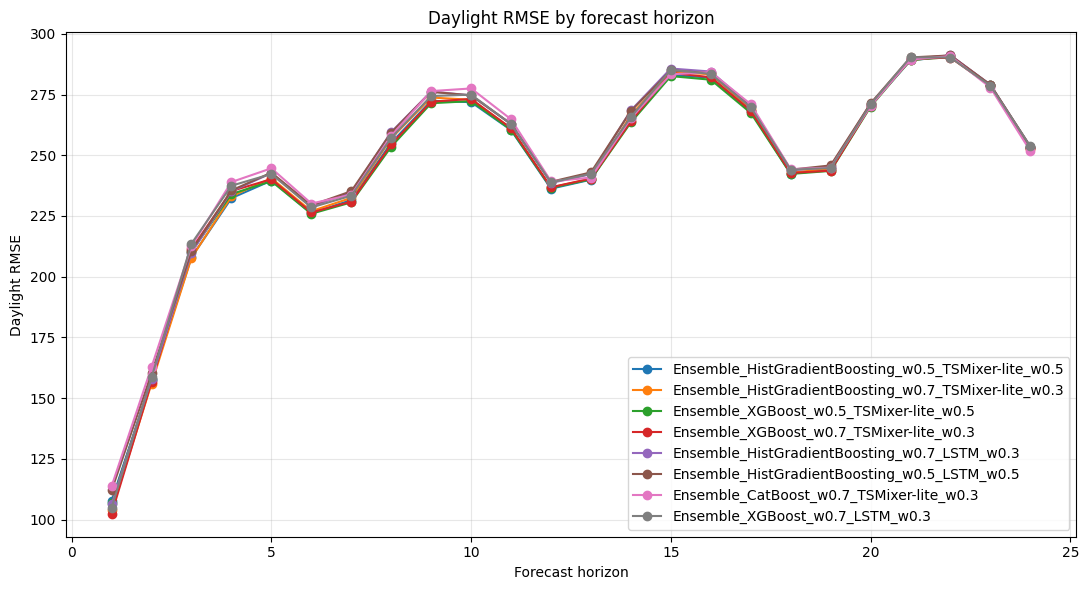

In [15]:
# =========================
# 15. Horizon-level metrics
# =========================

horizon_rows = []
for model_name, pred_obj in predictions.items():
    y_true = ensure_2d_prediction(pred_obj["test_true"])
    y_pred = ensure_2d_prediction(pred_obj["test_pred"])
    for h in range(HORIZON):
        yt = y_true[:, h]
        yp = y_pred[:, h]
        daylight_mask = yt > DAYLIGHT_THRESHOLD
        horizon_rows.append({
            "model": model_name,
            "horizon": h + 1,
            "RMSE": rmse(yt, yp),
            "MAE": float(mean_absolute_error(yt, yp)),
            "R2": float(r2_score(yt, yp)),
            "daylight_RMSE": rmse(yt[daylight_mask], yp[daylight_mask]) if daylight_mask.sum() > 5 else np.nan,
        })

horizon_df = pd.DataFrame(horizon_rows)
horizon_df.to_csv(OUT_DIR / "07_horizon_metrics.csv", index=False)

top_models_for_plot = results_df.head(8)["model"].tolist()

plt.figure(figsize=(11, 6))
for model_name in top_models_for_plot:
    tmp = horizon_df[horizon_df["model"] == model_name]
    plt.plot(tmp["horizon"], tmp["daylight_RMSE"], marker="o", label=model_name)
plt.xlabel("Forecast horizon")
plt.ylabel("Daylight RMSE")
plt.title("Daylight RMSE by forecast horizon")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_daylight_rmse_by_horizon.png", dpi=180)
plt.show()

In [16]:
# =========================
# 16. Daily-total-from-24h summary
# =========================

daily_rows = []
for model_name, pred_obj in predictions.items():
    true_total = ensure_2d_prediction(pred_obj["test_true"]).sum(axis=1)
    pred_total = ensure_2d_prediction(pred_obj["test_pred"]).sum(axis=1)
    daily_rows.append({
        "model": model_name,
        "daily_total_RMSE": rmse(true_total, pred_total),
        "daily_total_MAE": float(mean_absolute_error(true_total, pred_total)),
        "daily_total_R2": float(r2_score(true_total, pred_total)),
    })

daily_total_df = pd.DataFrame(daily_rows).sort_values("daily_total_RMSE")
daily_total_df.to_csv(OUT_DIR / "07_daily_total_from_24h_summary.csv", index=False)
display(daily_total_df.head(20))

,model,daily_total_RMSE,daily_total_MAE,daily_total_R2
41,Ensemble_XGBoost_w0.5_TSMixer-lite_w0.5,2330.785490,1566.099121,0.853392
42,Ensemble_XGBoost_w0.7_TSMixer-lite_w0.3,2331.420597,1580.411255,0.853312
17,Ensemble_HistGradientBoosting_w0.5_TSMixer-lit...,2331.668287,1562.973022,0.853281
18,Ensemble_HistGradientBoosting_w0.7_TSMixer-lit...,2332.065715,1575.201294,0.853231
40,Ensemble_XGBoost_w0.3_TSMixer-lite_w0.7,2343.747747,1569.319214,0.851757
16,Ensemble_HistGradientBoosting_w0.3_TSMixer-lit...,2344.526178,1567.965332,0.851659
53,Ensemble_Random Forest_w0.5_TSMixer-lite_w0.5,2346.918831,1587.412598,0.851356
52,Ensemble_Random Forest_w0.3_TSMixer-lite_w0.7,2348.391684,1576.582520,0.851169
29,Ensemble_CatBoost_w0.5_TSMixer-lite_w0.5,2349.035653,1574.114502,0.851087
21,Ensemble_HistGradientBoosting_w0.7_LSTM_w0.3,2350.675648,1600.922241,0.850879


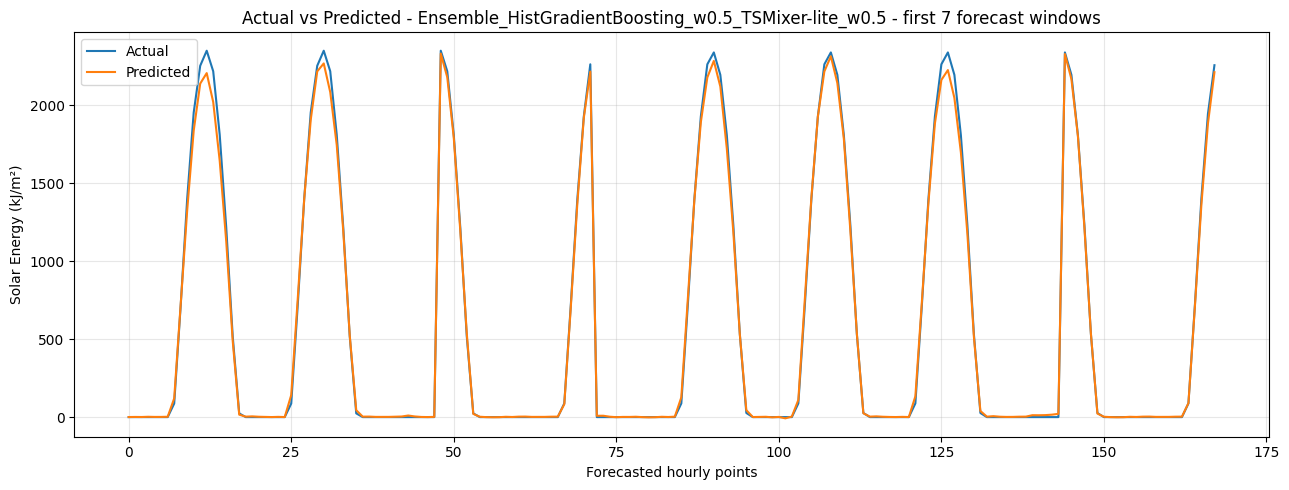

In [17]:
# =========================
# 17. Actual vs predicted plot for best model
# =========================

best_pred = predictions[best_model_name]
y_true_best = ensure_2d_prediction(best_pred["test_true"])
y_pred_best = ensure_2d_prediction(best_pred["test_pred"])

n_windows_to_plot = min(7, len(y_true_best))
plot_true = y_true_best[:n_windows_to_plot].reshape(-1)
plot_pred = y_pred_best[:n_windows_to_plot].reshape(-1)

plt.figure(figsize=(13, 5))
plt.plot(plot_true, label="Actual")
plt.plot(plot_pred, label="Predicted")
plt.title(f"Actual vs Predicted - {best_model_name} - first {n_windows_to_plot} forecast windows")
plt.xlabel("Forecasted hourly points")
plt.ylabel("Solar Energy (kJ/m²)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_best_model_actual_vs_predicted.png", dpi=180)
plt.show()

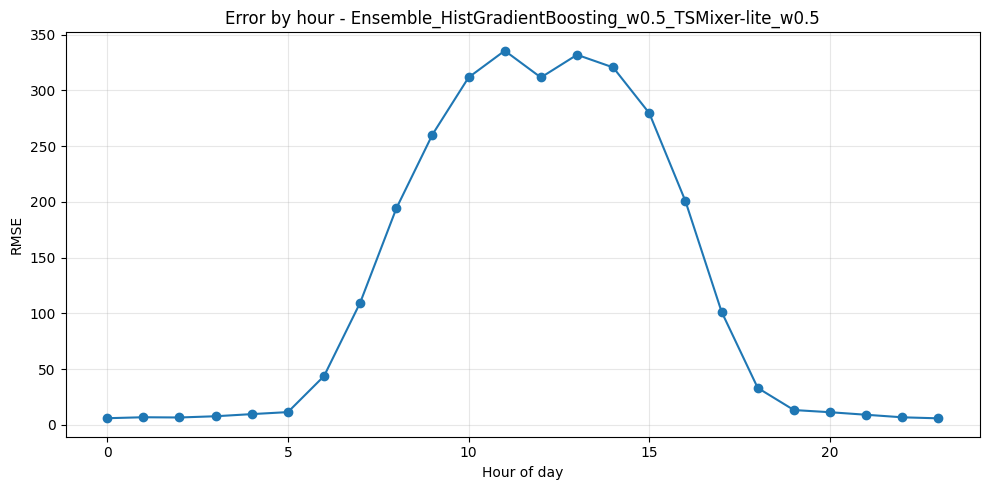

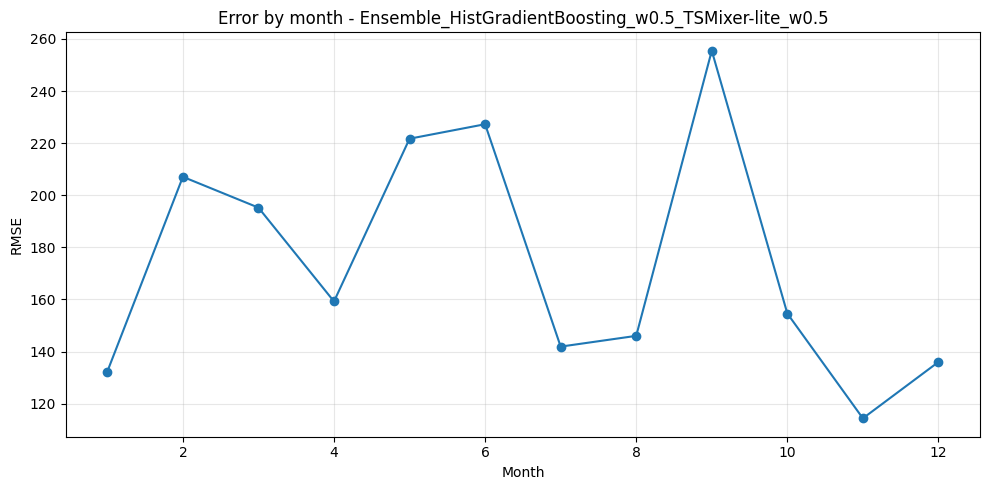

In [18]:
# =========================
# 18. Error analysis by hour and month
# =========================

error_rows = []
for i, anchor in enumerate(test_times[:len(y_true_best)]):
    future_times = pd.date_range(anchor, periods=HORIZON, freq="h")
    for h in range(HORIZON):
        yt = float(y_true_best[i, h])
        yp = float(y_pred_best[i, h])
        error_rows.append({
            "forecast_anchor": anchor,
            "target_time": future_times[h],
            "horizon": h + 1,
            "hour": future_times[h].hour,
            "month": future_times[h].month,
            "y_true": yt,
            "y_pred": yp,
            "error": yp - yt,
            "abs_error": abs(yp - yt),
            "squared_error": (yp - yt) ** 2,
            "is_daylight": yt > DAYLIGHT_THRESHOLD,
        })

error_df = pd.DataFrame(error_rows)

error_by_hour = error_df.groupby("hour").agg(
    RMSE=("squared_error", lambda x: float(np.sqrt(np.mean(x)))),
    MAE=("abs_error", "mean"),
    n=("abs_error", "size"),
).reset_index()
error_by_month = error_df.groupby("month").agg(
    RMSE=("squared_error", lambda x: float(np.sqrt(np.mean(x)))),
    MAE=("abs_error", "mean"),
    n=("abs_error", "size"),
).reset_index()

error_analysis_df = pd.concat([
    error_by_hour.assign(group="hour").rename(columns={"hour": "value"}),
    error_by_month.assign(group="month").rename(columns={"month": "value"}),
], ignore_index=True)
error_analysis_df.to_csv(OUT_DIR / "07_error_analysis.csv", index=False)

plt.figure(figsize=(10, 5))
plt.plot(error_by_hour["hour"], error_by_hour["RMSE"], marker="o")
plt.xlabel("Hour of day")
plt.ylabel("RMSE")
plt.title(f"Error by hour - {best_model_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_error_by_hour.png", dpi=180)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(error_by_month["month"], error_by_month["RMSE"], marker="o")
plt.xlabel("Month")
plt.ylabel("RMSE")
plt.title(f"Error by month - {best_model_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_error_by_month.png", dpi=180)
plt.show()

Best tabular model for feature importance: HistGradientBoosting


,feature,importance_mean,importance_std,model
80,anchor_hour_sin,904.202012,9.581130,HistGradientBoosting
81,anchor_hour_cos,373.731906,4.200563,HistGradientBoosting
1,Solar_Energy_kJ_m2_lag_2h,224.021261,1.482613,HistGradientBoosting
94,future_h12_solar_elevation,182.228571,0.683638,HistGradientBoosting
0,Solar_Energy_kJ_m2_lag_1h,180.680019,1.664500,HistGradientBoosting
16,sim_pv_ac_kWh_per_kWp_lag_1h,76.490616,2.115460,HistGradientBoosting
90,future_h1_solar_elevation,46.223687,2.222105,HistGradientBoosting
98,future_h24_solar_elevation,44.567700,1.282518,HistGradientBoosting
20,sim_pv_ac_kWh_per_kWp_lag_12h,31.897960,1.126883,HistGradientBoosting
38,Solar_Energy_kJ_m2_mean_24h,25.939336,1.913364,HistGradientBoosting


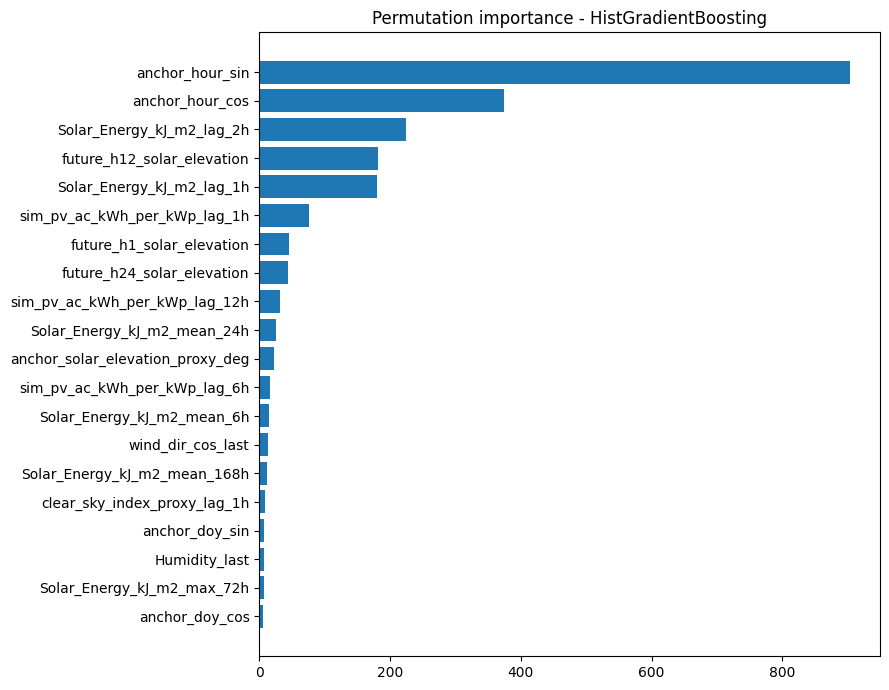

In [19]:
# =========================
# 19. Compact feature importance for best tabular model
# =========================

feature_importance_df = pd.DataFrame()

if RUN_PERMUTATION_IMPORTANCE:
    best_tabular_candidates = results_df[results_df["model_type"] == "tabular_or_boosting"]
    if not best_tabular_candidates.empty:
        best_tabular_name = best_tabular_candidates.iloc[0]["model"]
        best_tabular_model = tabular_predictions[best_tabular_name]["model"]
        print("Best tabular model for feature importance:", best_tabular_name)

        sample_n = min(500, len(X_test_tab))
        sample_idx = np.linspace(0, len(X_test_tab) - 1, sample_n).astype(int)
        X_perm = X_test_tab.iloc[sample_idx].copy()
        Y_perm = Y_test[sample_idx].copy()

        def scorer(estimator, X, y):
            pred = ensure_2d_prediction(estimator.predict(X))
            return -evaluate_24h(y, pred)["daylight_RMSE"]

        try:
            perm = permutation_importance(
                best_tabular_model,
                X_perm,
                Y_perm,
                scoring=scorer,
                n_repeats=2,
                random_state=SEED,
                n_jobs=1,
            )
            feature_importance_df = pd.DataFrame({
                "feature": X_perm.columns,
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std,
                "model": best_tabular_name,
            }).sort_values("importance_mean", ascending=False)

            feature_importance_df.to_csv(OUT_DIR / "07_feature_importance.csv", index=False)
            display(feature_importance_df.head(25))

            plt.figure(figsize=(9, 7))
            top = feature_importance_df.head(20).iloc[::-1]
            plt.barh(top["feature"], top["importance_mean"])
            plt.title(f"Permutation importance - {best_tabular_name}")
            plt.tight_layout()
            plt.savefig(FIG_DIR / "07_feature_importance.png", dpi=180)
            plt.show()
        except Exception as e:
            print("Permutation importance skipped due to error:", repr(e))
    else:
        print("No tabular model available for feature importance.")
else:
    print("Permutation importance disabled.")

In [20]:
# =========================
# 20. Save final compact comparison outputs
# =========================

final_summary = results_df[[
    c for c in [
        "model", "model_type",
        "val_daylight_RMSE", "test_daylight_RMSE",
        "test_RMSE", "test_R2",
        "test_h1_RMSE", "test_h12_RMSE", "test_h24_RMSE",
        "test_daily_total_RMSE", "test_daily_total_R2",
        "test_skill_vs_persistence_daylight",
        "train_seconds",
    ] if c in results_df.columns
]].copy()

final_summary.to_csv(OUT_DIR / "07_final_summary_for_report.csv", index=False)
if not training_history_df.empty:
    training_history_df.to_csv(OUT_DIR / "07_training_history.csv", index=False)

print("Saved outputs to:", OUT_DIR)
print("Saved figures to:", FIG_DIR)
print("Saved models to:", MODEL_DIR)
display(final_summary.head(20))
print("Notebook 07 completed.")

Saved outputs to: outputs_07
Saved figures to: figures_07
Saved models to: models_07


,model,model_type,val_daylight_RMSE,test_daylight_RMSE,test_RMSE,test_R2,test_h1_RMSE,test_h12_RMSE,test_h24_RMSE,test_daily_total_RMSE,test_daily_total_R2,test_skill_vs_persistence_daylight,train_seconds
0,Ensemble_HistGradientBoosting_w0.5_TSMixer-lit...,ensemble,225.298301,248.767446,179.136296,0.976102,80.270840,173.070580,185.098506,2331.624541,0.853287,0.267306,0.0
1,Ensemble_HistGradientBoosting_w0.7_TSMixer-lit...,ensemble,225.447298,249.323060,179.479940,0.976010,77.054297,173.363582,184.917993,2331.978023,0.853242,0.265670,0.0
2,Ensemble_XGBoost_w0.5_TSMixer-lite_w0.5,ensemble,225.659848,248.564724,178.969959,0.976146,79.583897,173.281202,185.372935,2330.437191,0.853436,0.267903,0.0
3,Ensemble_XGBoost_w0.7_TSMixer-lite_w0.3,ensemble,225.803703,248.953011,179.193337,0.976087,76.013761,173.378582,185.202687,2330.600245,0.853415,0.266760,0.0
4,Ensemble_HistGradientBoosting_w0.7_LSTM_w0.3,ensemble,226.245787,250.756932,180.547724,0.975724,78.862308,174.671136,185.513592,2350.629384,0.850885,0.261447,0.0
5,Ensemble_HistGradientBoosting_w0.5_LSTM_w0.5,ensemble,226.378002,251.039978,180.851885,0.975642,83.442939,175.073350,185.715151,2360.074787,0.849684,0.260613,0.0
6,Ensemble_CatBoost_w0.7_TSMixer-lite_w0.3,ensemble,226.469248,251.044031,180.756775,0.975667,84.465972,175.329712,184.220115,2359.348851,0.849777,0.260601,0.0
7,Ensemble_XGBoost_w0.7_LSTM_w0.3,ensemble,226.492222,250.450727,180.293949,0.975792,77.782559,174.807176,185.618939,2350.550680,0.850895,0.262349,0.0
8,Ensemble_CatBoost_w0.5_TSMixer-lite_w0.5,ensemble,226.497051,250.325164,180.275115,0.975797,85.673395,174.871203,185.061751,2349.305642,0.851053,0.262718,0.0
9,Ensemble_XGBoost_w0.5_LSTM_w0.5,ensemble,226.608297,250.912405,180.722919,0.975677,82.711315,175.424975,185.776285,2360.438836,0.849638,0.260989,0.0


Notebook 07 completed.
